In [76]:
##TASK 1:
##Load and understand the dataset.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [78]:
df=pd.read_csv("data/netflix_titles.csv")

In [79]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [80]:
df.shape

(8807, 12)

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [131]:
#TASK 2:
#Perform data cleaning (missing values, duplicates, data types).

In [132]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      98
month_added     98
day_added       98
dtype: int64

In [133]:
df.duplicated().sum()

np.int64(0)

In [134]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
year_added             float64
month_added                str
day_added              float64
dtype: object

In [135]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')

In [136]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
year_added             float64
month_added                str
day_added              float64
dtype: object

In [137]:
#filling the missing values in the director column with unknown
df['director']=df['director'].fillna('unknown')

In [138]:
#checking if any missing value are left in the director column
df['director'].isnull().sum()

np.int64(0)

In [139]:
#filling missing values in the cast column with unknown
df['cast']=df['cast'].fillna('unknown')

In [140]:
#checking if any missing value are left in the cast column
df['cast'].isnull().sum()

np.int64(0)

In [141]:
#filling missing values in the country column with unknown
df['country']=df['country'].fillna('unknown')

In [142]:
#checking if any missing value are left in the country column
df['country'].isnull().sum()

np.int64(0)

In [143]:
#filling missing values in the rating column with unknown
df['rating']=df['rating'].fillna('unknown')

In [144]:
#checking if any missing value are left in the rating column
df['rating'].isnull().sum()

np.int64(0)

In [145]:
#filling missing values in the duration column with unknown
df['duration']=df['duration'].fillna('unknown')

In [146]:
#checking if any missing value are left in the duration column
df['duration'].isnull().sum()

np.int64(0)

In [147]:
# Exploratory Data Analysis (EDA)
#Task 3

In [148]:
#count the numeber of movies and tv shows in the dataset
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

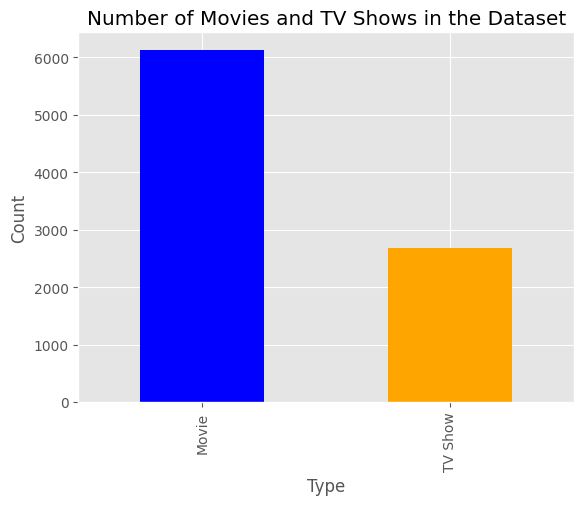

In [149]:
#plotting the number of movies and tv shows in the dataset
df['type'].value_counts().plot(kind='bar',color=['blue','orange'])

plt.title('Number of Movies and TV Shows in the Dataset')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [150]:
#observation:
#The Netflix dataset contains significantly more movies than TV shows.

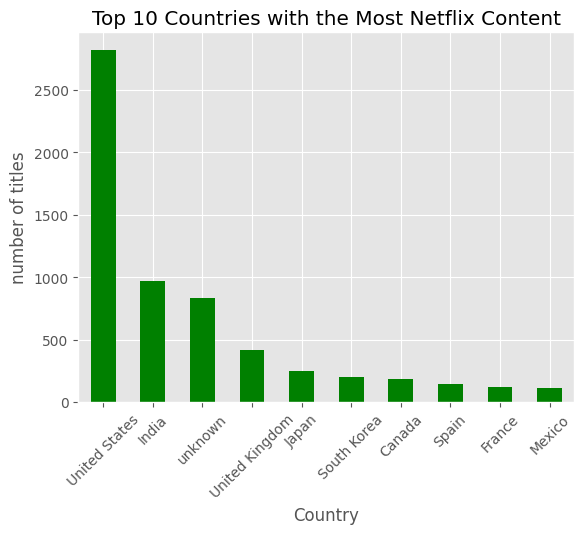

In [151]:
#Top 10 countries with the most Netflix content
df['country'].value_counts().head(10).plot(kind='bar',color='green')
plt.title('Top 10 Countries with the Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('number of titles')
plt.xticks(rotation=45) 
plt.show()

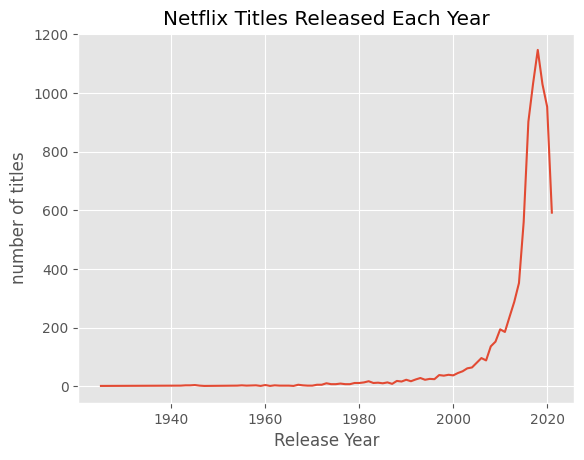

In [152]:
#count titles released each year
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title('Netflix Titles Released Each Year')
plt.xlabel('Release Year')
plt.ylabel('number of titles')
plt.show()

In [153]:
# Observation:
# Netflix content releases grew slowly until 2000.
# The number of titles increased rapidly after 2015.
# The highest number of titles was released around 2018–2019.
# After 2019, the number of releases decreased slightly.

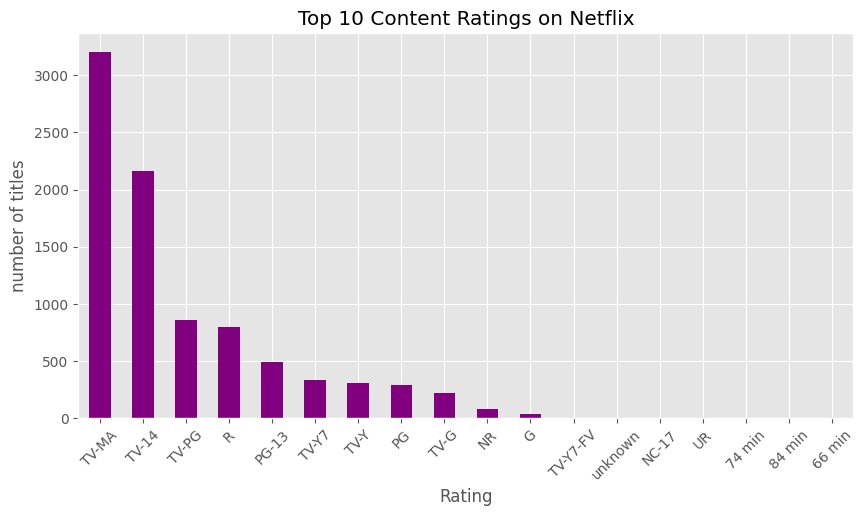

In [154]:
#count different content ratings
df['rating'].value_counts().plot(kind='bar',color='purple',figsize=(10,5))
plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('number of titles')
plt.xticks(rotation=45)
plt.show()

In [155]:
# Observation:
# TV-MA is the most common content rating on Netflix.
# TV-14 is the second most common rating.
# Netflix mainly offers content intended for mature audiences.

In [156]:
#count Movies and TV shows released each year
release_type=df.groupby(['release_year','type']).size().unstack().fillna(0)

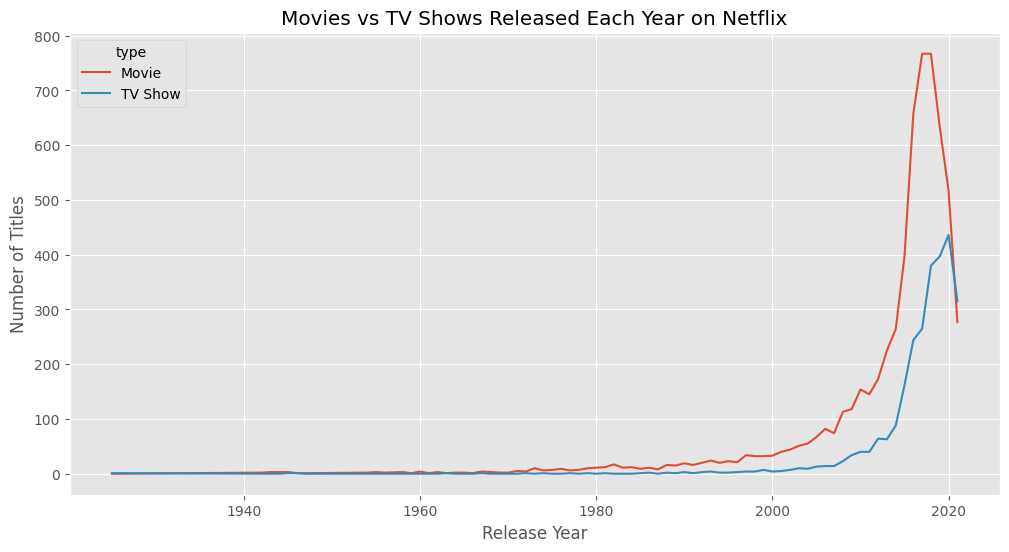

In [157]:
# ploting Movies vs TV shows released each year
release_type.plot(kind='line',figsize=(12,6))
plt.title('Movies vs TV Shows Released Each Year on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

In [158]:
# Observation:
# Movies are more numerous than TV Shows in almost every year.
# Both Movies and TV Shows increased rapidly after 2015.
# The number of releases peaks around 2019.
# There is a decline after 2019, likely because the dataset was collected before the year was complete.

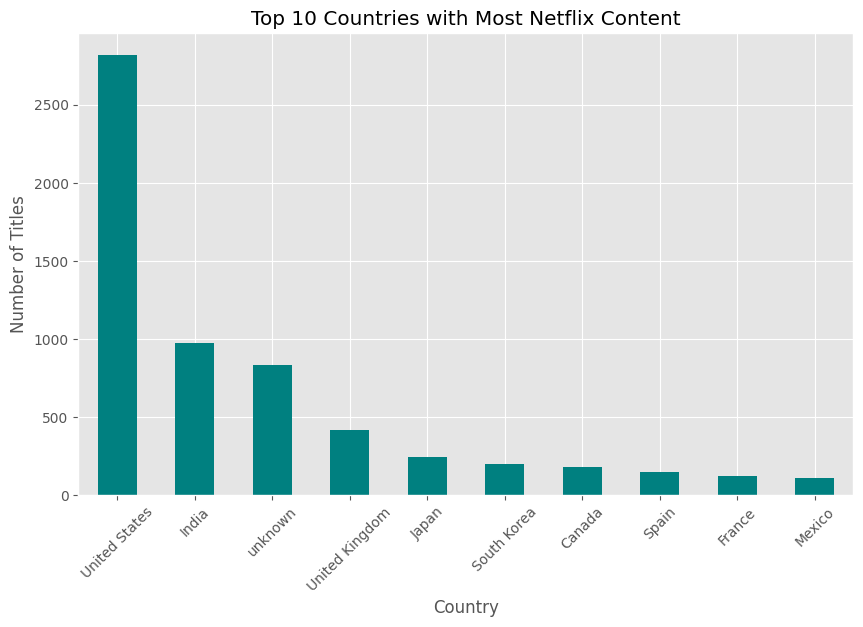

In [159]:
# Top 10 countries with the most Netflix content
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_country.plot(kind='bar', color='teal')

plt.title('Top 10 Countries with Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

In [160]:
#Task 4:
#Create meaningful visualizations using Matplotlib & Seaborn

In [161]:
#visualization 1:top 10 genres


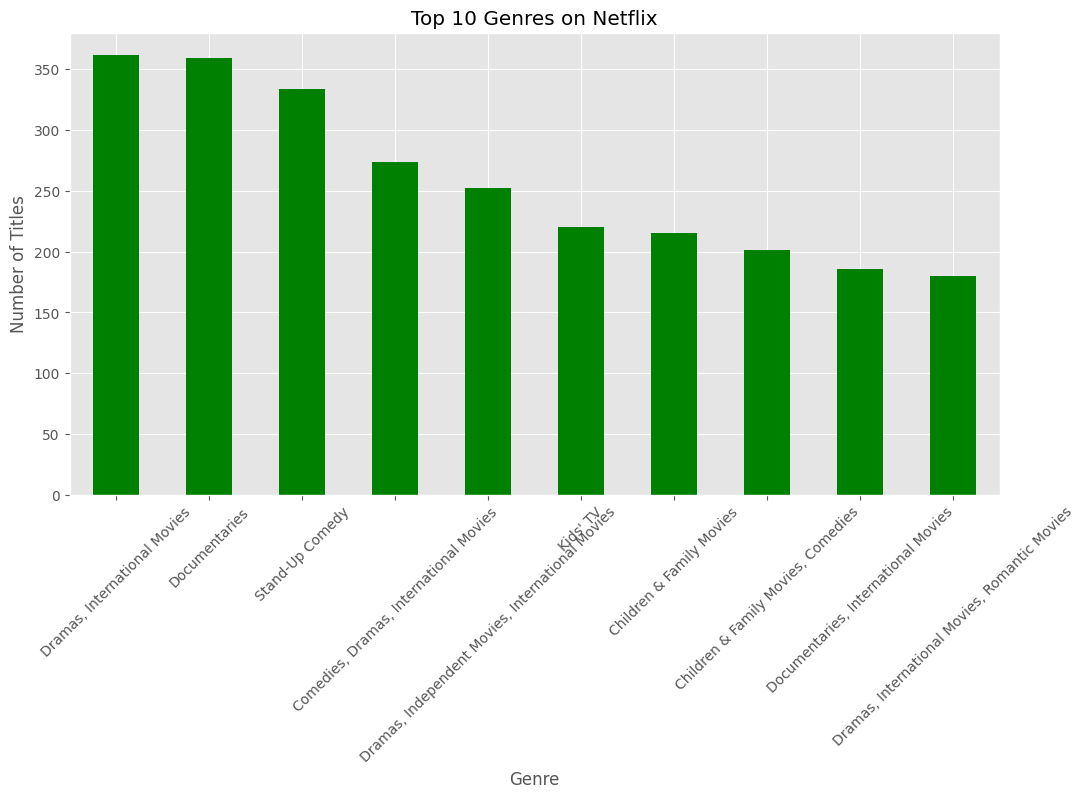

In [162]:
#counting the top 10 genres
top_genres = df['listed_in'].value_counts().head(10)

#creating the figure
plt.figure(figsize=(12,6))

#plotting the bar chart
top_genres.plot(kind='bar', color='green')

#Add title and labels
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
#rotate x-axis labels
plt.xticks(rotation=45)
plt.show()


In [163]:

# Observation:
# Dramas and International Movies are the most common genres on Netflix.
# Documentaries and Stand-Up Comedy also have a large number of titles.
# Netflix offers content across many genres, showing a diverse content library.

In [164]:
##VISUALIZATION OF TOP 10 DIRECTORS 

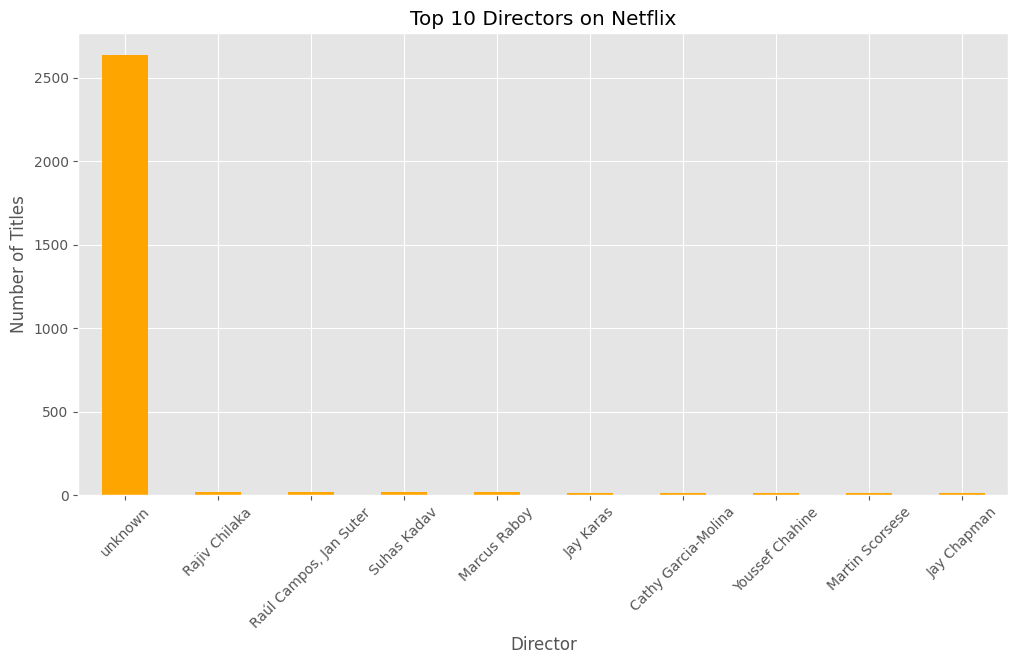

In [165]:
# Count the top 10 directors
top_directors = df['director'].value_counts().head(10)

# Create the figure
plt.figure(figsize=(12,6))

# Plot the bar chart
top_directors.plot(kind='bar', color='orange')

# Add title and labels
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Display the graph
plt.show()

In [166]:
# Observation:
# After removing unknown values, the graph shows the top 10 directors with the highest number of titles on Netflix.
# This provides a more accurate comparison of directors' contributions.

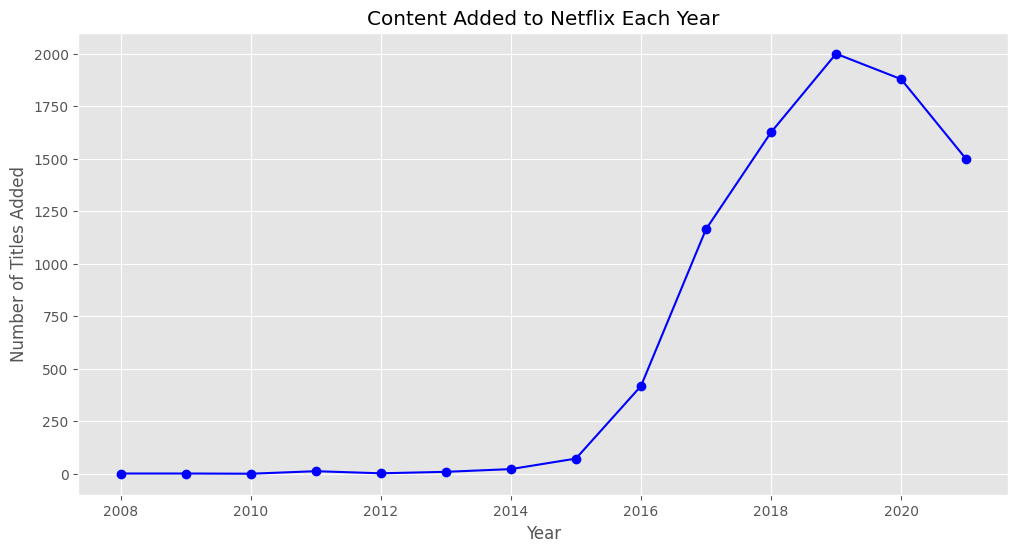

In [167]:
# Count titles added each year
content_added = df['date_added'].dt.year.value_counts().sort_index()

# Create figure
plt.figure(figsize=(12,6))

# Plot line chart
content_added.plot(kind='line', marker='o', color='blue')

# Add title and labels
plt.title('Content Added to Netflix Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

# Display graph
plt.show()

In [168]:
# Observation:
# Netflix added very few titles before 2015.
# The number of titles increased rapidly from 2016 onward.
# Content additions reached their peak around 2019 and then declined slightly in 2020 and 2021.

In [169]:
## VISUALIZATION OF TOP 10 RELEASE YEARS

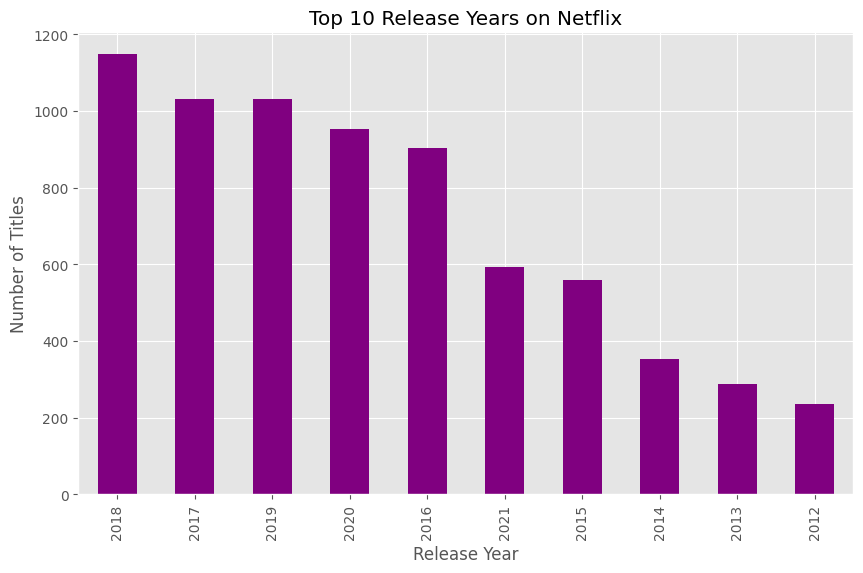

In [170]:
# Count the top 10 release years
top_years = df['release_year'].value_counts().head(10)

# Create figure
plt.figure(figsize=(10,6))

# Plot bar chart
top_years.plot(kind='bar', color='purple')

# Add title and labels
plt.title('Top 10 Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

# Display graph
plt.show()

In [171]:
# Observation:
# Most Netflix titles were released between 2016 and 2020.
# The highest number of titles in the dataset were released in 2018.
# This indicates that Netflix's content library mainly consists of recent releases.

In [172]:
##TASK 5:
#Perform feature engineering

In [173]:
# Create new features from the date_added column
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df['day_added'] = df['date_added'].dt.day

# Display the first five rows of the new columns
df[['date_added', 'year_added', 'month_added', 'day_added']].head()

,date_added,year_added,month_added,day_added
0,2021-09-25,2021.0,September,25.0
1,2021-09-24,2021.0,September,24.0
2,2021-09-24,2021.0,September,24.0
3,2021-09-24,2021.0,September,24.0
4,2021-09-24,2021.0,September,24.0


In [174]:
# Feature Engineering:
# Extracted year, month, and day from the date_added column.
# These new features help analyze when content was added to Netflix.

In [175]:
# Selecting only movies
movies = df[df['type'] == 'Movie'].copy()

# Extracting only the number from duration
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)')[0]

# Convert to numeric (invalid values become NaN)
movies['duration_min'] = pd.to_numeric(movies['duration_min'], errors='coerce')

# Remove rows having NaN duration
movies = movies.dropna(subset=['duration_min'])

# Convert float to integer
movies['duration_min'] = movies['duration_min'].astype(int)

# Display first five rows
movies[['title', 'duration', 'duration_min']].head()

,title,duration,duration_min
0,Dick Johnson Is Dead,90 min,90
6,My Little Pony: A New Generation,91 min,91
7,Sankofa,125 min,125
9,The Starling,104 min,104
12,Je Suis Karl,127 min,127


In [176]:
##TASK 6:
#Detect and handle outliers

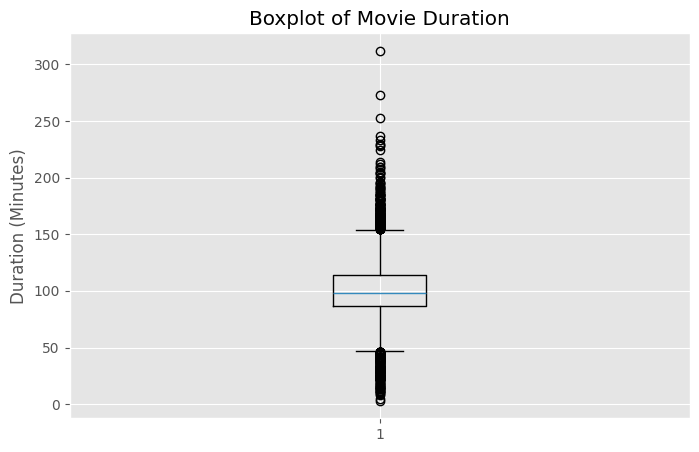

In [177]:


plt.figure(figsize=(8,5))
plt.boxplot(movies['duration_min'])
plt.title('Boxplot of Movie Duration')
plt.ylabel('Duration (Minutes)')
plt.show()

In [178]:
# Calculate Quartiles
Q1 = movies['duration_min'].quantile(0.25)
Q3 = movies['duration_min'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 87.0
Q3: 114.0
IQR: 27.0
Lower Limit: 46.5
Upper Limit: 154.5


In [179]:
# Detect outliers
outliers = movies[
    (movies['duration_min'] < lower_limit) |
    (movies['duration_min'] > upper_limit)
]

print("Number of Outliers:", len(outliers))
outliers.head()

Number of Outliers: 450


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added,duration_min
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",unknown,2021-09-21,1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...,2021.0,September,21.0,161
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,2021.0,September,21.0,166
45,s46,Movie,My Heroes Were Cowboys,Tyler Greco,unknown,unknown,2021-09-16,2021,PG,23 min,Documentaries,Robin Wiltshire's painful childhood was rescue...,2021.0,September,16.0,23
71,s72,Movie,A StoryBots Space Adventure,David A. Vargas,"Evan Spiridellis, Erin Fitzgerald, Jeff Gill, ...",unknown,2021-09-14,2021,TV-Y,13 min,Children & Family Movies,Join the StoryBots and the space travelers of ...,2021.0,September,14.0,13
73,s74,Movie,King of Boys,Kemi Adetiba,"Sola Sobowale, Adesua Etomi, Remilekun ""Remini...",Nigeria,2021-09-14,2018,TV-MA,182 min,"Dramas, International Movies",When a powerful businesswoman’s political ambi...,2021.0,September,14.0,182


In [180]:
movies_clean = movies[
    (movies['duration_min'] >= lower_limit) &
    (movies['duration_min'] <= upper_limit)
]

print("Original Shape:", movies.shape)
print("Clean Shape:", movies_clean.shape)

Original Shape: (6128, 16)
Clean Shape: (5678, 16)
